<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 11: Testing</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part III: Systems Integration — SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

**Part 1: Test Methodology**
1. [Test Environment](#1-test-environment)
2. [DC Characterization](#2-dc-characterization)
3. [Margin Testing](#3-margin-testing)
4. [Functional Testing](#4-functional-testing)
5. [Speed and Timing](#5-speed-timing)
6. [On-Chip Test Structures](#6-test-structures)
7. [Common Failure Modes](#7-failure-modes)
8. [Debug Strategies](#8-debug-strategies)
9. [Yield and Statistics](#9-yield-statistics)
10. [Practical Measurement Setup](#10-practical-setup) ← **Start here if things don't work**
    - 10.1 Grounding: The #1 Source of Problems
        - Star Ground Topology
        - Power Strips and AC Wiring
        - AC Safety vs Signal Ground
        - Isolated Rack Wiring
        - Computer Connections
    - 10.2 Thermoelectric Effects
    - 10.3 Common Wiring Mistakes
    - 10.4 Measurement Checklist
    - 10.5 Best Practice Configuration
    - 10.6 Chassis vs. Isolated Grounding
    - 10.7 Dry Cryocooler vs. LHe Systems
        - Compressor Ground Bounce
        - Isolation Transformers
        - Ferrites (What They Actually Do)
        - Ground Loops Through Signal Cables
        - USB/Fiber Isolators

18. [Equipment and Vendor Guide](#18-equipment-vendors)

**Infrastructure (see other lectures):**
- Cryogenic Systems → Lecture 10
- Packaging & I/O → Lecture 9

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

**Part 1: Test Methodology**
- Set up and operate a cryogenic test environment
- Perform DC characterization of Josephson junctions
- Measure and interpret operating margins
- Design effective on-chip test structures
- Diagnose common failure modes in SCE circuits
- Apply systematic debug strategies
- Understand yield metrics and statistical analysis

**Part 2: Test Equipment Construction**
- Design and build an LHe dip probe
- Configure a rackmount cryocooler test system
- Calculate and manage thermal budgets
- Implement proper signal integrity (coax selection, filtering)
- Design star-ground systems and avoid ground loops
- Construct multi-layer magnetic shielding
- Wire a complete cryogenic test system

---

In [1]:
# Setup
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np

COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'warning': '#FFC107',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'aqfp': '#00BCD4',
    'rsfq': '#9C27B0'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Physical constants
Phi_0 = 2.067833848e-15  # Wb
k_B = 1.380649e-23       # J/K

print("Setup complete.")

Setup complete.


---
<a id="1-test-environment"></a>
# 1. Test Environment
---

Testing superconducting circuits requires specialized cryogenic infrastructure.

### Cryogenic Systems

| System | Base Temp | Hold Time | Use Case |
|--------|-----------|-----------|----------|
| **LHe Dewar (dip probe)** | 4.2 K | Hours | Quick characterization |
| **Closed-cycle cryocooler** | 3-4 K | Continuous | Production testing |
| **Dilution refrigerator** | 10-20 mK | Continuous | Quantum circuits |
| **ADR (Adiabatic Demag)** | <100 mK | Hours | Low-T characterization |

For AQFP and RSFQ testing, **4.2 K systems** (liquid helium or cryocoolers) are standard.

### Test Setup Block Diagram

```
    Room Temperature                      4.2 K
    ───────────────────────────────────────────────────────
    
    ┌─────────────┐     Coax/Flex      ┌─────────────────┐
    │   Pattern   │─────────────────►  │                 │
    │  Generator  │                    │   Magnetic      │
    └─────────────┘                    │   Shielding     │
                                       │  ┌───────────┐  │
    ┌─────────────┐     Filtered       │  │           │  │
    │    Bias     │─────────────────►  │  │    DUT    │  │
    │   Sources   │     lines          │  │   (Chip)  │  │
    └─────────────┘                    │  │           │  │
                                       │  └───────────┘  │
    ┌─────────────┐                    │        │        │
    │   Readout   │◄─────────────────  │        ▼        │
    │   (Scope/   │     Output         │   Cryo Amps     │
    │   Counter)  │     lines          │   (optional)    │
    └─────────────┘                    └─────────────────┘
```

### Wiring Considerations

| Wire Type | Thermal Load | Bandwidth | Use |
|-----------|--------------|-----------|-----|
| **Stainless coax** | Low | DC-1 GHz | Bias, slow signals |
| **NbTi coax** | Very low | DC-10 GHz | SC below 4K, moderate BW |
| **CuNi coax** | Medium | DC-20 GHz | High-speed I/O |
| **Phosphor bronze twisted pair** | Low | DC-1 MHz | DC bias |

### Thermal Budget

Every wire conducts heat. A 4K cryocooler typically provides:
- **1st stage (40-50 K)**: 30-50 W
- **2nd stage (4 K)**: 1-2 W

Heat loads to manage:
- Wiring: ~1-10 mW per coax
- Radiation: Minimized by shielding
- Chip dissipation: µW to mW (depends on circuit)

---
<a id="2-dc-characterization"></a>
# 2. DC Characterization
---

DC measurements verify that Josephson junctions and basic circuit elements are functional.

### Junction I-V Curve

The most fundamental measurement is the current-voltage characteristic.

**Key parameters extracted:**

| Parameter | Symbol | Typical Value | What It Tells You |
|-----------|--------|---------------|-------------------|
| Critical current | I_c | 50-500 µA | Junction size, quality |
| Normal resistance | R_n | 1-20 Ω | Barrier quality |
| I_c × R_n product | - | 1-2 mV | Material quality figure of merit |
| Subgap resistance | R_sg | >10 × R_n | Junction quality |
| Gap voltage | V_g | 2.8 mV (Nb) | 2Δ/e, superconductor gap |

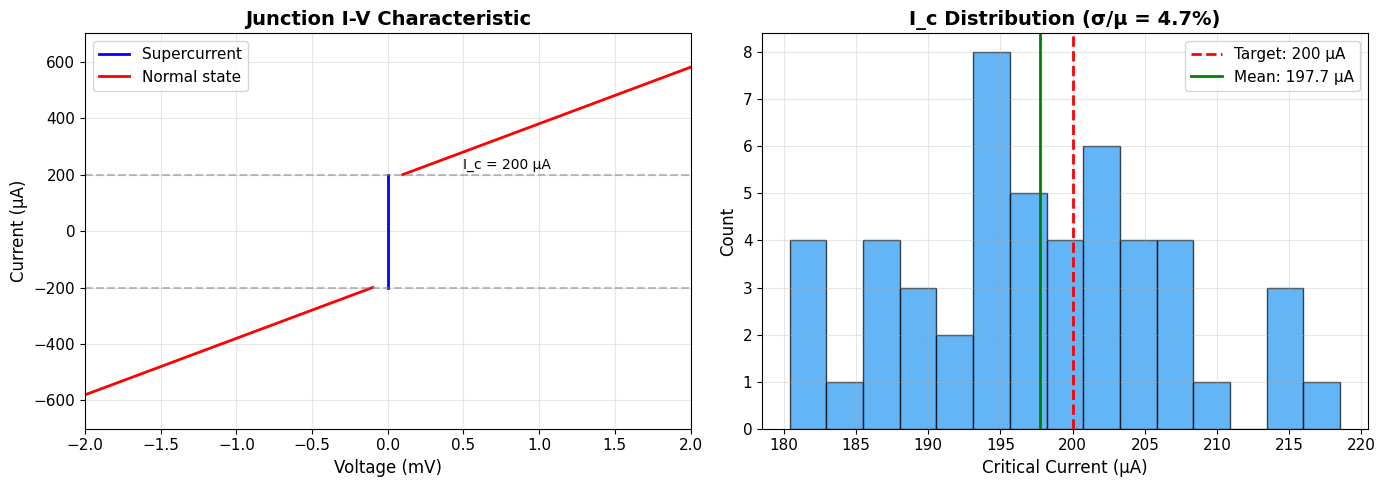

I_c × R_n = 1.00 mV (target: 1-2 mV for Nb/AlOx/Nb)


In [2]:
# Simulate and plot a JJ I-V curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Ideal I-V curve
I_c = 200e-6  # 200 µA
R_n = 5       # 5 Ω
V_g = 2.8e-3  # 2.8 mV gap voltage

# Supercurrent branch
I_super = np.linspace(-I_c, I_c, 100)
V_super = np.zeros_like(I_super)

# Normal branch (simplified RSJ model)
I_normal_pos = np.linspace(I_c, 3*I_c, 100)
V_normal_pos = (I_normal_pos - I_c) * R_n + 0.1e-3  # Small offset for visibility

I_normal_neg = np.linspace(-3*I_c, -I_c, 100)
V_normal_neg = (I_normal_neg + I_c) * R_n - 0.1e-3

ax1.plot(V_super*1e3, I_super*1e6, 'b-', linewidth=2, label='Supercurrent')
ax1.plot(V_normal_pos*1e3, I_normal_pos*1e6, 'r-', linewidth=2, label='Normal state')
ax1.plot(V_normal_neg*1e3, I_normal_neg*1e6, 'r-', linewidth=2)

ax1.axhline(I_c*1e6, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(-I_c*1e6, color='gray', linestyle='--', alpha=0.5)
ax1.text(0.5, I_c*1e6 + 20, f'I_c = {I_c*1e6:.0f} µA', fontsize=10)

ax1.set_xlabel('Voltage (mV)', fontsize=12)
ax1.set_ylabel('Current (µA)', fontsize=12)
ax1.set_title('Junction I-V Characteristic', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(-2, 2)
ax1.set_ylim(-700, 700)

# Right: I_c variation across wafer (simulated)
np.random.seed(42)
n_junctions = 50
I_c_measured = I_c * (1 + 0.05 * np.random.randn(n_junctions))  # 5% variation

ax2.hist(I_c_measured*1e6, bins=15, color=COLORS['primary'], edgecolor='black', alpha=0.7)
ax2.axvline(I_c*1e6, color='red', linestyle='--', linewidth=2, label=f'Target: {I_c*1e6:.0f} µA')
ax2.axvline(np.mean(I_c_measured)*1e6, color='green', linestyle='-', linewidth=2, 
            label=f'Mean: {np.mean(I_c_measured)*1e6:.1f} µA')

ax2.set_xlabel('Critical Current (µA)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'I_c Distribution (σ/μ = {np.std(I_c_measured)/np.mean(I_c_measured)*100:.1f}%)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"I_c × R_n = {I_c * R_n * 1e3:.2f} mV (target: 1-2 mV for Nb/AlOx/Nb)")

### DC Test Structures

Include these on every chip for process monitoring:

| Structure | Purpose | Measurement |
|-----------|---------|-------------|
| **Single JJ** | I_c, R_n extraction | I-V curve |
| **JJ array (series)** | I_c uniformity | I-V shows weakest junction |
| **Sheet resistance** | Verify metal layers | 4-point probe |
| **Contact resistance** | Via/contact quality | Kelvin structure |
| **Inductance test** | L/square verification | SQUID or resonance |

### Measurement Best Practices

1. **Use 4-wire sensing** — Eliminates lead resistance errors
2. **Current bias, not voltage bias** — JJs are current-controlled devices
3. **Filter inputs** — Prevent noise-induced switching
4. **Ramp slowly** — Avoid transient heating
5. **Multiple sweeps** — Check for hysteresis and repeatability

---
<a id="3-margin-testing"></a>
# 3. Margin Testing
---

**Operating margins** quantify how robust a circuit is to parameter variations. This is the most critical metric for circuit functionality.

### What Are Margins?

Margins measure the range over which a bias parameter can vary while the circuit still operates correctly:

$$\text{Margin} = \frac{X_{max} - X_{min}}{X_{nominal}} \times 100\%$$

where X is the bias parameter (current, voltage, or excitation amplitude).

### Types of Margins

| Margin Type | Typical Target | What It Tests |
|-------------|----------------|---------------|
| **Bias current** | ±15-25% | DC operating point |
| **Excitation amplitude** (AQFP) | ±20-25% | Clock/power delivery |
| **Clock timing** | ±10-20% of period | Setup/hold times |
| **Input amplitude** | ±15-20% | Signal integrity |
| **Temperature** | ±0.5-1 K | Thermal stability |

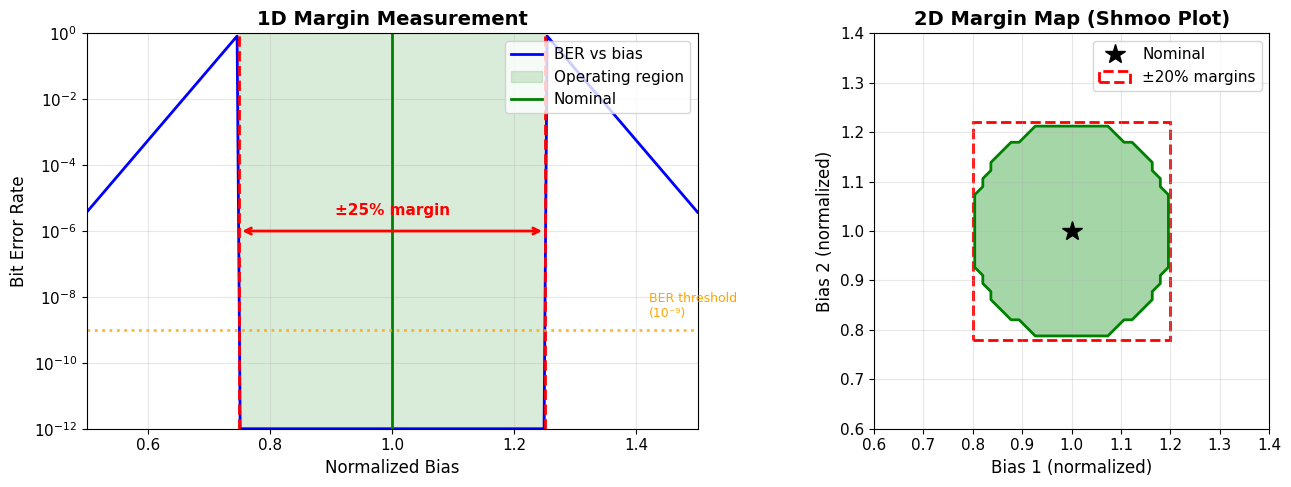

Left: BER drops to unmeasurable levels within the operating region.
      Circuit passes when BER < threshold (e.g., 10⁻⁹) across the full margin range.
Right: Green = pass, white = fail. Goal: green region contains the ±20% box.


In [3]:
# Visualize margin measurement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: 1D margin plot
bias = np.linspace(0.5, 1.5, 200)
# Simulated bit error rate vs bias
ber = np.where((bias > 0.75) & (bias < 1.25), 0, 
               np.exp(-50*(np.minimum(np.abs(bias-0.75), np.abs(bias-1.25)))))

ax1.semilogy(bias, ber + 1e-12, 'b-', linewidth=2, label='BER vs bias')

# Shade the operating region (between margin boundaries)
ax1.axvspan(0.75, 1.25, alpha=0.15, color='green', label='Operating region')

# Margin boundaries
ax1.axvline(0.75, color='red', linestyle='--', linewidth=2)
ax1.axvline(1.25, color='red', linestyle='--', linewidth=2)
ax1.axvline(1.0, color='green', linestyle='-', linewidth=2, label='Nominal')

# BER threshold line
ax1.axhline(1e-9, color='orange', linestyle=':', linewidth=2, alpha=0.8)
ax1.text(1.42, 2e-9, 'BER threshold\n(10⁻⁹)', fontsize=9, color='orange', va='bottom')

# Margin annotation
ax1.annotate('', xy=(0.75, 1e-6), xytext=(1.25, 1e-6),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(1.0, 3e-6, '±25% margin', ha='center', fontsize=11, color='red', fontweight='bold')

ax1.set_xlabel('Normalized Bias', fontsize=12)
ax1.set_ylabel('Bit Error Rate', fontsize=12)
ax1.set_title('1D Margin Measurement', fontsize=14, fontweight='bold')
ax1.set_ylim(1e-12, 1)
ax1.set_xlim(0.5, 1.5)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: 2D margin map (shmoo plot)
x = np.linspace(0.6, 1.4, 50)
y = np.linspace(0.6, 1.4, 50)
X, Y = np.meshgrid(x, y)

# Operating region is roughly elliptical
Z = ((X - 1.0)**2 / 0.2**2 + (Y - 1.0)**2 / 0.22**2) < 1

ax2.contourf(X, Y, Z.astype(float), levels=[0.5, 1.5], colors=[COLORS['success']], alpha=0.5)
ax2.contour(X, Y, Z.astype(float), levels=[0.5], colors=['green'], linewidths=2)
ax2.plot(1.0, 1.0, 'k*', markersize=15, label='Nominal')

# Draw margin box
rect = plt.Rectangle((0.8, 0.78), 0.4, 0.44, fill=False, edgecolor='red', 
                       linestyle='--', linewidth=2, label='±20% margins')
ax2.add_patch(rect)

ax2.set_xlabel('Bias 1 (normalized)', fontsize=12)
ax2.set_ylabel('Bias 2 (normalized)', fontsize=12)
ax2.set_title('2D Margin Map (Shmoo Plot)', fontsize=14, fontweight='bold')
ax2.set_aspect('equal')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: BER drops to unmeasurable levels within the operating region.")
print("      Circuit passes when BER < threshold (e.g., 10⁻⁹) across the full margin range.")
print("Right: Green = pass, white = fail. Goal: green region contains the ±20% box.")

### Margin Measurement Procedure

**1D Margin Sweep:**
1. Set all biases to nominal
2. Apply test pattern (e.g., PRBS, walking ones)
3. Sweep one bias from low to high
4. Record pass/fail at each point
5. Find lower and upper boundaries
6. Repeat for each bias

**2D Margin Map (Shmoo Plot):**

A **shmoo plot** is a 2D pass/fail map showing how a circuit behaves across two swept parameters. The name comes from Al Capp's 1940s cartoon character whose blob-like shape resembles typical pass regions. It's standard terminology in semiconductor testing.

1. Choose two critical biases
2. Sweep both in a grid pattern
3. Record pass/fail at each (x, y) point
4. Visualize as a 2D map (green = pass, white = fail)
5. Reveals correlations between parameters

### Interpreting Shmoo Plots

| Pattern | Interpretation | Action |
|---------|---------------|--------|
| Large, centered region | Good design | Ship it |
| Small region | Marginal design | Redesign or screen |
| Off-center region | Nominal values wrong | Re-target biases |
| Irregular shape | Multiple failure modes | Investigate edges |
| Holes in region | Intermittent failures | Check for noise, flux |

---
<a id="4-functional-testing"></a>
# 4. Functional Testing
---

Functional testing verifies that the circuit performs its intended logic operation.

### Test Pattern Types

| Pattern | Purpose | Coverage |
|---------|---------|----------|
| **Exhaustive** | All input combinations | 100% (small circuits only) |
| **Walking ones/zeros** | Stuck-at faults | Basic connectivity |
| **PRBS** | Random patterns | Statistical coverage |
| **ATPG** (Auto Test Pattern Gen) | Targeted fault coverage | Specific faults |
| **Functional vectors** | Real use cases | Application-specific |

### Test Architecture

For complex circuits, build in test infrastructure with shift registers at I/O:

```mermaid
flowchart LR
    subgraph chip[Chip]
        direction TB
        IN[Input<br/>Shift Reg] --> CUT[Circuit<br/>Under Test]
        CUT --> OUT[Output<br/>Shift Reg]
    end
    
    TI[Test<br/>Input] --> IN
    OUT --> TO[Test<br/>Output]

    style CUT fill:#E3F2FD,stroke:#1976D2,stroke-width:2px
    style IN fill:#C8E6C9
    style OUT fill:#C8E6C9
```

Shift registers allow serial loading/unloading of test vectors, reducing pin count.

### Scan Chain Architecture

In CMOS, **scan chains** insert a mux at each flip-flop to enable shift-register mode:

```
  scan_enable ─────────────────────────────────┐
                                               │
  Serial In ──► [MUX→DFF] ──► [MUX→DFF] ──► [MUX→DFF] ──► Serial Out
                  │              │              │
                  ▼              ▼              ▼
             Circuit Node   Circuit Node   Circuit Node
```

Each scan cell:
- `scan_enable = 0`: MUX passes functional data — chip runs normally
- `scan_enable = 1`: MUX passes scan data — shift register mode for test vectors

**AQFP Considerations:**

| Aspect | CMOS | AQFP |
|--------|------|------|
| Scan mux cost | ~2 transistors | Full MAJ gate per cell |
| Clock overhead | Minimal | Extra phases for mux + DFF |
| Shift register | Standard | Chain of clocked buffers (straightforward) |
| scan_enable routing | Simple wire | Must distribute to all cells |

The overhead in AQFP is significant: a mux at every scan point plus global scan_enable routing. For large designs, consider scan only at block boundaries rather than every flip-flop.

### Speed Considerations

| Test Mode | Speed | Purpose |
|-----------|-------|--------|
| **Low-speed scan** | kHz-MHz | Debug, pattern loading |
| **At-speed functional** | GHz | Verify timing margins |
| **Overdrive** | >nominal | Stress testing |

### Pass/Fail Criteria

- **Bit Error Rate (BER)**: Typically require BER < 10⁻¹² for production
- **Pattern match**: All output bits match expected values
- **Timing**: Outputs arrive within specified window

---
<a id="5-speed-timing"></a>
# 5. Speed and Timing
---

### Maximum Frequency Testing

To find the maximum operating frequency:

1. Start at a known-good low frequency
2. Run functional test pattern
3. Increment frequency
4. Repeat until errors appear
5. Back off to find reliable maximum

### Timing Measurements

| Measurement | Method | Precision |
|-------------|--------|----------|
| **Propagation delay** | Input-to-output time | ~10 ps |
| **Setup time** | Clock-to-data timing | ~10 ps |
| **Hold time** | Data-to-clock timing | ~10 ps |
| **Jitter** | Edge-to-edge variation | ~1 ps RMS |

### AQFP Timing Characteristics

In AQFP, timing is determined by the **external AC excitation**:

- **Clock frequency** = excitation frequency (typically 5-10 GHz)
- **Stage delay** = 1/4 clock period (one phase step)
- **Pipeline latency** = N stages × stage delay

Timing extraction approach:
1. Measure output vs. excitation phase relationship
2. Sweep excitation frequency to find margins
3. Characterize setup/hold by shifting input timing relative to excitation

### Frequency Margin Testing

For AQFP, designs typically work from DC (any low frequency) up to a maximum frequency set by timing margins. This is unlike RSFQ which has both lower and upper frequency limits.

The operating frequency range reveals timing margins in the design. Sweeping frequency while monitoring error rate identifies the maximum reliable operating point.

---
<a id="6-test-structures"></a>
# 6. On-Chip Test Structures
---

Every chip should include **Process Control Monitors (PCMs)** to diagnose issues.

### Essential Test Structures

| Structure | What It Measures | Failure Indication |
|-----------|------------------|-------------------|
| **Single JJ (multiple sizes)** | I_c, R_n vs. area | Process variation |
| **JJ chain (series)** | I_c uniformity | Weak junction in chain |
| **Sheet R (each metal)** | Layer resistance | Deposition issues |
| **Via chain** | Contact resistance | Etch/clean problems |
| **Inductor (known L)** | Inductance | Layer thickness |
| **SQUID magnetometer** | Ambient field | Shielding verification |
| **Margin monitor** | Single gate margins | Process centering |
| **Buffer chain** | Stage delay, signal integrity | Timing verification |

### Test Structure Placement

PCMs are typically placed wherever space permits — often in gaps between bond pads or in unused corners. There's no single standard; placement depends on available area and what you need to monitor.

### SQUID-Based Field Monitor

A simple DC SQUID can verify your magnetic shielding:

- Measure I_c modulation vs. applied field
- Offset from expected curve indicates ambient field at the chip
- Useful for confirming shielding is working before cooldown through T_c

**Note:** SQUIDs measure ambient field, not trapped flux. Trapped flux in the circuit itself must be inferred from circuit behavior (margin shifts, cooldown-dependent failures).

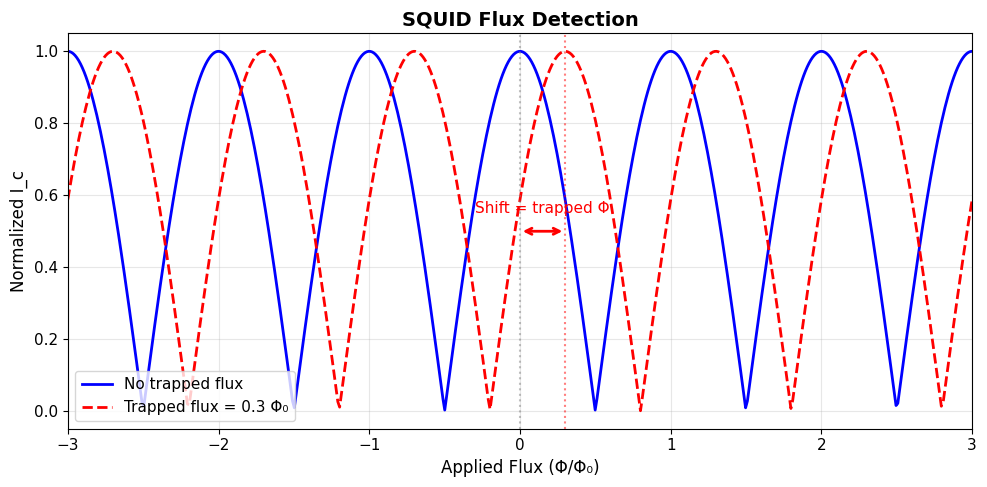

The shift in the SQUID modulation curve reveals trapped flux.
Multiple SQUIDs across the chip can map the flux distribution.


In [4]:
# Visualize SQUID flux detection
fig, ax = plt.subplots(figsize=(10, 5))

# SQUID I_c vs flux
phi = np.linspace(-3, 3, 500)  # flux in units of Φ₀
I_c_squid = np.abs(np.cos(np.pi * phi))  # Idealized SQUID modulation

# Without trapped flux (centered)
ax.plot(phi, I_c_squid, 'b-', linewidth=2, label='No trapped flux')

# With trapped flux (shifted)
phi_trapped = 0.3  # 0.3 Φ₀ trapped
ax.plot(phi, np.abs(np.cos(np.pi * (phi - phi_trapped))), 'r--', linewidth=2, 
        label=f'Trapped flux = {phi_trapped} Φ₀')

ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(phi_trapped, color='red', linestyle=':', alpha=0.5)

ax.annotate('', xy=(phi_trapped, 0.5), xytext=(0, 0.5),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(phi_trapped/2, 0.55, 'Shift = trapped Φ', ha='center', fontsize=11, color='red')

ax.set_xlabel('Applied Flux (Φ/Φ₀)', fontsize=12)
ax.set_ylabel('Normalized I_c', fontsize=12)
ax.set_title('SQUID Flux Detection', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

print("The shift in the SQUID modulation curve reveals trapped flux.")
print("Multiple SQUIDs across the chip can map the flux distribution.")

---
<a id="7-failure-modes"></a>
# 7. Common Failure Modes
---

Understanding failure modes helps focus debug efforts.

### Fabrication-Related Failures

These are typically caught by the fab's process control monitors before chips ship. Included here for completeness, but circuit designers rarely see these directly.

| Failure | Symptom | Root Cause |
|---------|---------|------------|
| **Open junction** | No I_c, high R | Barrier too thick, lithography |
| **Shorted junction** | No R_n, low R | Barrier pinholes, particles |
| **I_c too low** | Reduced margins | Barrier thick, oxidation |
| **I_c too high** | Reduced margins, excess power | Barrier thin |
| **Open via** | No connectivity | Etch residue, undercut |
| **Metal short** | Unintended connection | Particles, lithography |
| **Metal open** | No connectivity | Over-etch, particles |

### Design-Related Failures

| Failure | Symptom | Root Cause |
|---------|---------|------------|
| **Path imbalance** | Wrong output values | Unequal delays to gate |
| **Insufficient margin** | Intermittent errors | Undersized JJs or L |
| **Crosstalk** | Pattern-dependent errors | Inadequate spacing |
| **Missing splitter** | Fan-out failure | Forgot fan-out > 1 |
| **Wrong polarity** | Inverted logic | Transformer winding error |

### Environment-Related Failures

| Failure | Symptom | Root Cause |
|---------|---------|------------|
| **Flux trapping** | Random errors per cooldown | Ambient field, shielding |
| **Temperature drift** | Margin variation | Cryostat instability |
| **EMI pickup** | Burst errors | Inadequate filtering |
| **Ground loops** | Offset, noise | Wiring topology |

---
<a id="8-debug-strategies"></a>
# 8. Debug Strategies
---

Systematic debug is essential when circuits fail.

### Debug Flowchart

```
    Circuit fails
         │
         ▼
    ┌─────────────┐     No      ┌─────────────────┐
    │ PCMs pass?  │────────────►│ Fabrication     │
    └──────┬──────┘             │ issue - check   │
           │ Yes                │ wafer lot       │
           ▼                    └─────────────────┘
    ┌─────────────┐     No      ┌─────────────────┐
    │ DC biases   │────────────►│ Setup issue -   │
    │ correct?    │             │ check wiring    │
    └──────┬──────┘             └─────────────────┘
           │ Yes
           ▼
    ┌─────────────┐     No      ┌─────────────────┐
    │ Margins     │────────────►│ Marginal design │
    │ centered?   │             │ or process edge │
    └──────┬──────┘             └─────────────────┘
           │ Yes
           ▼
    ┌─────────────┐     No      ┌─────────────────┐
    │ Repeatable  │────────────►│ Flux trapping   │
    │ across      │             │ or intermittent │
    │ cooldowns?  │             │ connection      │
    └──────┬──────┘             └─────────────────┘
           │ Yes
           ▼
    ┌─────────────────────────────────────────────┐
    │ Pattern-dependent failure - check design   │
    │ (path balance, fan-out, polarity)          │
    └─────────────────────────────────────────────┘
```

### Isolation Techniques

1. **Binary search**: Test half the circuit, narrow down
2. **Known-good substitution**: Replace suspected block
3. **Boundary scan**: Observe internal nodes via shift registers
4. **Bias walking**: Vary one bias while monitoring output
5. **Pattern reduction**: Simplify test pattern to isolate failure

### Correlation Analysis

When failures occur:
- **Lot correlation**: Same wafer lot? → Fab issue
- **Position correlation**: Same die location? → Mask defect
- **Cooldown correlation**: Random per cooldown? → Flux trapping
- **Pattern correlation**: Same input pattern? → Design issue
- **Time correlation**: Drift over hours? → Thermal or bias drift

---
<a id="9-yield-statistics"></a>
# 9. Yield and Statistics
---

### Yield Models

Random defects occur at roughly **~0.1 defects/cm² per metal layer**. Circuit yield follows the Poisson area model:

$$Y = e^{-d \cdot L \cdot A}$$

where:
- d = defect density per layer (~0.1/cm²)
- L = number of metal layers
- A = chip area (cm²)

AQFP designs use **4 layers** (M4–M7), not the full 8-layer SFQ5ee stack — halving defect exposure.

| Chip Area | 4-layer yield (AQFP) | 8-layer yield (full stack) |
|-----------|---------------------|---------------------------|
| 0.1 cm² | 96% | 92% |
| 0.5 cm² | 82% | 67% |
| 1.0 cm² | 67% | 45% |
| 2.0 cm² | 45% | 20% |

The gap between this random-defect floor and real-world yield (10–25% for complex circuits today) is dominated by **design-side** issues: flux trapping during cooldown, clock margin violations across large die, and unintended electromagnetic coupling. These are engineering problems with known solutions that improve with design maturity — not just fab maturity. Yield is improving at ~4%/month.

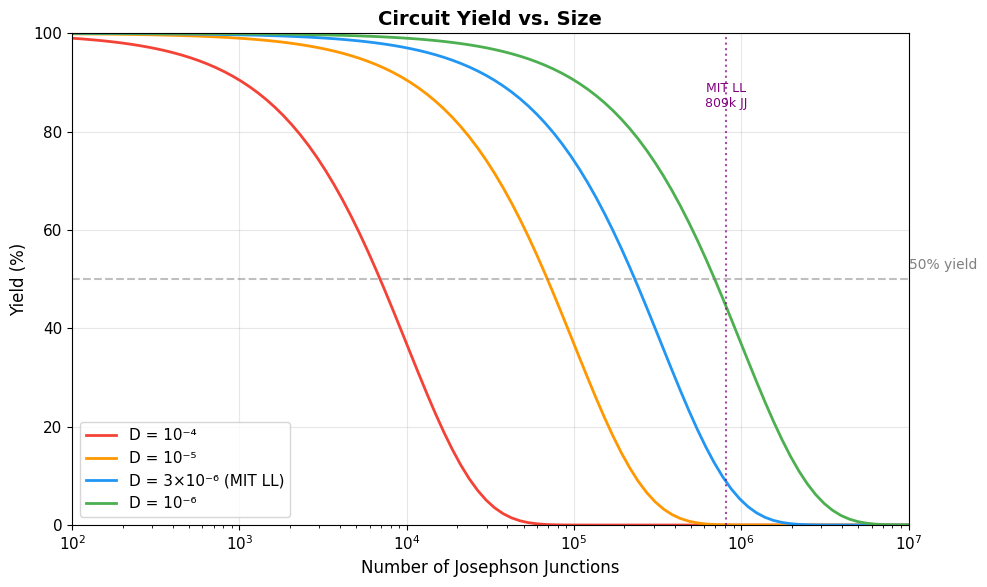

Yield improvement requires reducing defect density D.
Current state-of-the-art (MIT LL): D ≈ 3×10⁻⁶
Target for million-junction circuits: D < 10⁻⁶


In [5]:
# Yield vs chip area for different layer counts
fig, ax = plt.subplots(figsize=(10, 6))

d = 0.1  # defects/cm² per metal layer
areas = np.linspace(0.01, 3.0, 200)

layer_configs = [
    (8, 'Full SFQ5ee (8 layers)', COLORS['danger'], '--'),
    (4, 'AQFP (4 layers, M4–M7)', COLORS['success'], '-'),
]

for L, label, color, ls in layer_configs:
    Y = np.exp(-d * L * areas) * 100
    ax.plot(areas, Y, color=color, linewidth=2, linestyle=ls, label=label)

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.text(2.8, 52, '50% yield', fontsize=10, color='gray')

ax.set_xlabel('Chip Area (cm²)', fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title('Circuit Yield vs. Chip Area', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 3.0)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Yield improvement comes from two paths:")
print("  1. Reduce defect density d (fab process maturation)")
print("  2. Use fewer layers (AQFP: 4 vs full-stack SFQ: 8)")
print()
print("Note: This model captures random fabrication defects only.")
print("The yield gap to real-world (10-25% for complex circuits) is mostly")
print("design-side: flux trapping, clock margin violations, EM coupling.")
print("These improve with design maturity, not just fab maturity (~4%/month).")

### Statistical Sampling

For production testing, statistical methods are essential:

| Method | Sample Size | Purpose |
|--------|-------------|--------|
| **100% test** | All | High-value parts |
| **Lot sampling** | n per lot | Process monitoring |
| **SPC (Statistical Process Control)** | Continuous | Trend detection |
| **DOE (Design of Experiments)** | Structured | Process optimization |

### Yield Learning

Track these metrics over time to drive improvement:

1. **First-pass yield**: % working on first test
2. **Final yield**: % working after debug/rework
3. **Yield by failure mode**: Which defects dominate?
4. **Yield vs. circuit size**: Extracting defect density
5. **Yield vs. wafer position**: Edge effects, gradients

---
<a id="10-practical-setup"></a>
# 10. Practical Measurement Setup
---

**This section covers the practical issues that actually break measurements.** Theory is nice, but if your ground connection has 500 mΩ resistance, nothing will work.

## 10.1 Grounding: The #1 Source of Problems

### The Ground Impedance Problem

In µV-level Josephson junction measurements, **ground resistance matters**:

| Ground Connection | Typical R | Effect with 100 µA bias |
|-------------------|-----------|------------------------|
| Good: direct chassis connection | <1 mΩ | <0.1 µV offset |
| Acceptable: gold-plated connector | 1-10 mΩ | 0.1-1 µV offset |
| **PROBLEM: thin wire bond** | 50-200 mΩ | **5-20 µV offset** |
| **PROBLEM: long flex cable return** | 100-500 mΩ | **10-50 µV offset** |
| **FAILURE: corroded connector** | >1 Ω | **>100 µV - measurement fails** |

**Example failure**: You're measuring an I-V curve on a junction. The voltage steps should be ~100-200 µV. But your ground return goes through a corroded SMA connector (2 Ω). With 200 µA bias current:

$$V_{offset} = I_{bias} \times R_{ground} = 200\,\mu A \times 2\,\Omega = 400\,\mu V$$

This offset completely obscures your signal.

### Star Ground Topology

**Rule: All grounds connect at exactly ONE point.**

```
                     ┌─────────────────────────────────────┐
                     │          STAR GROUND POINT          │
                     │      (Cryostat chassis, single      │
                     │       bolt with star washer)        │
                     └─────────┬───────────────────────────┘
                               │
          ┌────────────────────┼────────────────────┐
          │                    │                    │
          ▼                    ▼                    ▼
    ┌───────────┐        ┌───────────┐        ┌───────────┐
    │ Bias      │        │ Readout   │        │ Pattern   │
    │ Source    │        │ (DMM)     │        │ Generator │
    └───────────┘        └───────────┘        └───────────┘
    
    WRONG: Instrument 1 ground ──► DUT ──► Instrument 2 ground
           (This creates a ground LOOP)
```

**Ground loop symptoms:**
- 50/60 Hz hum on all signals (100 mV - 1 V amplitude)
- Measurements change when you touch cables
- Results vary depending on which instrument is powered on first

### Practical Star Ground: Power Strips and AC Wiring

**The problem with power strips:**

```
WRONG - Multiple power strips create ground loops:

Wall outlet A ── Power strip 1 ── Instrument 1 ──┐
                      │                          │
                      └── ground path A          │ Signal cables
                                                 │ connect them
Wall outlet B ── Power strip 2 ── Instrument 2 ──┘
                      │
                      └── ground path B
                      
Outlets A and B have different ground potentials (sometimes 10-100 mV).
Current flows through your signal cables between instruments.
```

**RIGHT - Single power distribution point:**

```
                    ┌─────────────────────────┐
Wall outlet ─────── │  Isolation Transformer  │
(or panel)          │     (if isolated)       │
                    └───────────┬─────────────┘
                                │
                    ┌───────────▼─────────────┐
                    │   Main Power Strip /    │
                    │   Power Distribution    │
                    │   Unit (PDU)            │
                    └───────────┬─────────────┘
                                │
          ┌─────────────────────┼─────────────────────┐
          │                     │                     │
          ▼                     ▼                     ▼
    ┌───────────┐         ┌───────────┐         ┌───────────┐
    │  Source   │         │   DAQ /   │         │ Computer  │
    │           │         │   DMM     │         │           │
    └───────────┘         └───────────┘         └───────────┘
    
All instruments share the SAME AC ground through ONE power strip.
```

### The Two Grounds: AC Safety vs. Signal Ground

People often confuse these:

| Ground Type | Purpose | Where It Connects |
|-------------|---------|-------------------|
| **AC Safety Ground** | Protect humans from shock | Green wire in AC cord, instrument chassis |
| **Signal Ground** | Reference for measurements | BNC shields, signal return paths |

**They should connect at exactly ONE point** - typically at your star ground (cryostat chassis or main rack ground bus).

```
Instrument Chassis ─────┬───── AC Safety Ground (green wire)
                        │
                        └───── Signal Ground (BNC shields)
                               │
                               ▼
                        STAR GROUND POINT
                        (ONE connection only)
```

**Common mistake**: An instrument has its signal ground connected to chassis (normal), AND you run a separate ground wire from the BNC shield to the rack. Now you have two paths = loop.

### Isolated Rack Wiring Example

Here's a complete isolated measurement rack setup:

```
Building Power
      │
      ▼
┌─────────────────────────────────────────────────────────────────┐
│                    ISOLATION TRANSFORMER                         │
│                    (e.g., Tripp Lite IS1000)                    │
└─────────────────────────────┬───────────────────────────────────┘
                              │
                              │ Isolated AC (secondary)
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│                     ISOLATED POWER STRIP                         │
│   (all measurement equipment plugs in here)                      │
│                                                                  │
│    ┌─────────┐  ┌─────────┐  ┌─────────┐  ┌─────────┐          │
│    │ Bias    │  │ DMM     │  │ DAQ     │  │ Preamp  │          │
│    │ Source  │  │         │  │         │  │         │          │
│    └────┬────┘  └────┬────┘  └────┬────┘  └────┬────┘          │
│         │            │            │            │                 │
│         └────────────┴─────┬──────┴────────────┘                │
│                            │                                     │
│                            ▼                                     │
│                   RACK GROUND BUS                                │
│                   (copper bar, one point)                        │
│                            │                                     │
└────────────────────────────┼────────────────────────────────────┘
                             │
                             │ Single heavy gauge wire
                             ▼
                    CRYOSTAT CHASSIS
                    (Star ground point)
```

**Key points:**
1. **One isolation transformer** feeds everything on the isolated side
2. **One power strip** - all instruments plug into the same strip
3. **Rack ground bus** - a copper bar where all chassis grounds connect
4. **Single connection** from rack ground bus to cryostat chassis

### What About the Computer?

The DAQ computer is tricky - it needs to talk to isolated instruments but often sits on building power.

**Option 1: Computer on isolated side (cleanest)**
```
Isolation TX ── Power strip ──┬── DAQ
                              ├── Source
                              └── Computer (laptop works well)
```

**Option 2: USB isolator (practical)**
```
Isolated side                          Building power side
                                       
DAQ ──── USB ──── [USB Isolator] ──── USB ──── Desktop Computer
                  (ADuM4160 or similar)
```

**Option 3: Ethernet/fiber (best for noisy environments)**
```
Isolated side                          Building power side
                                       
DAQ with ──── Fiber optic ──────────────────── Computer
Ethernet       or Ethernet
               (no galvanic connection)
```

### Checklist: Power and Grounding

**For isolated measurement rack:**

- [ ] Single isolation transformer feeds all measurement equipment
- [ ] All instruments on ONE power strip (not multiple strips/outlets)
- [ ] Rack ground bus (copper bar) connects all chassis
- [ ] Single heavy-gauge wire from rack ground bus to cryostat
- [ ] Computer either on isolated side OR connected via isolator/fiber
- [ ] No "extra" ground wires between instruments (one path only)

**Quick test:** Unplug one instrument's AC. Does any other instrument's reading change? If yes, you have a ground loop through signal cables.

### Coax Shield Grounding

**Single-end grounding only:** Ground the coax shield at the warm end (feedthrough). Let it float at the cold end.

Why? A shield grounded at both ends creates a ground loop between 300K and 4K. Temperature-dependent thermoelectric voltages and coupled noise will flow through this loop.

**But the chip still needs ground.** The distinction:

| What | Grounding Rule | Why |
|------|---------------|-----|
| Coax shields | Warm end ONLY | Prevents 300K-4K ground loops |
| PCB ground plane | Single point to chassis | Star topology |
| Chip ground pads | Multiple wirebonds to PCB | Low inductance RF return |

The chip's ground comes from the PCB ground plane (via multiple wirebonds for low RF inductance). The PCB connects to the cryostat chassis at ONE point (star ground). This is NOT a ground loop - it's all the same ground plane.

**Common confusion**: "Single-end grounding" applies to the *coax shield path from room temp to 4K*. It does NOT mean "only one wirebond to chip ground." You want many ground wirebonds for low-inductance RF return - they all connect to the same PCB ground plane.

### RF Return Current: The Shield Grounding Tradeoff

There's a real tension between DC ground loop prevention and RF signal integrity.

**The problem:** At RF frequencies, return current *wants* to flow on the inner surface of the coax shield (skin effect, lowest inductance). If the shield is truly floating at the cold end, the RF return must find another path — through the PCB ground plane, up whatever wires exist — creating a larger loop area and degrading transmission line behavior.

**What actually happens:** The shield typically connects to the PCB ground plane at the cold end (providing an RF return path). "Single-end grounding" means no *separate* shield-to-chassis connection at cold — the path is shield → PCB ground → star point → chassis.

**The remaining loop:** Even so, a DC path exists: warm shield → chassis → star point → PCB ground → cold shield. Thermoelectric voltages can drive current through this loop.

**Options for critical RF lines:**

| Approach | How It Works | Tradeoff |
|----------|--------------|----------|
| **AC-couple shield at cold end** | Capacitor in shield path passes RF, blocks DC | Adds complexity; need cryo-compatible cap |
| **Accept it and filter aggressively** | Attenuators + filters at each stage | What most qubit labs do |
| **Superconducting coax at 4K** | SC shield has zero DC resistance | Expensive; no thermoelectric voltage in SC |

**AC coupling option:** A capacitor (10 nF - 1 µF, rated for cryo) in series with the shield at the cold end passes RF return current but blocks DC ground loops. This preserves transmission line behavior while eliminating the thermoelectric path. Cryo-compatible ceramic capacitors (C0G/NP0 dielectric) work well — standard MLCC from Murata, TDK, or Kemet. Avoid X7R/X5R dielectrics which lose capacitance at cryo.

**Frequency tradeoffs for AC coupling:** The capacitor impedance varies with frequency:

| Frequency | 100 nF Impedance | Effect |
|-----------|------------------|--------|
| 60 Hz | ~27 kΩ | Blocks ground loop noise |
| 1 kHz | ~1.6 kΩ | Some impedance for test signals |
| 10 kHz | ~160 Ω | Reasonable coupling |
| 1 MHz | ~1.6 Ω | Good coupling |
| 1 GHz | ~1.6 mΩ | Essentially shorted (normal operation) |

At kHz frequencies, transmission line behavior doesn't matter — wavelength is hundreds of km, so the cable is electrically short. The return current will find a path through the PCB ground even if the shield impedance is elevated. Signal integrity at kHz is forgiving.

**If you need good kHz coupling** (for low-frequency testing), options include: larger capacitor (1 µF, harder to find in C0G), or install a jumper footprint to bypass the cap during testing. In practice, most labs just accept the DC loop and filter aggressively — kHz test signals work fine even with the ground loop present.

### Two-Domain Ground Isolation Architecture

For the most sensitive measurements (µV-level AQFP signals), even a well-designed star ground may not be sufficient. The cryostat body inherently couples to building ground through the compressor and cold head — this creates a noise path.

**The solution: Two completely separate ground domains.**

```
                      ┌─────────────────────────────────────────────┐
                      │              DOMAIN 1 (EARTH)               │
                      │                                             │
Building Mains ──────►│ Compressor ──► Cold Head ──► Cryostat Body │
(Earth Ground)        │                                             │
                      └─────────────────────────────────────────────┘
                                              ║
                                    ╔═════════╩═════════╗
                                    ║  ALUMINA DISK     ║
                                    ║  (breaks galvanic ║
                                    ║   path at 4K)     ║
                                    ╚═════════╦═════════╝
                                              ║
                      ┌─────────────────────────────────────────────┐
                      │            DOMAIN 2 (ISOLATED)              │
                      │                                             │
Isolation TX ────────►│ Readout Electronics ──► Dedicated Ground   │
(Floating Secondary)  │ (amps, DAQ)              Wires ──► 4K PCB  │
                      │                                             │
                      └─────────────────────────────────────────────┘
```

**Key elements:**

| Element | Purpose |
|---------|---------|
| **Alumina disk** | Electrically insulating, thermally conductive ceramic between cold finger and 4K backplane. Breaks the galvanic path from cryostat body to measurement ground. |
| **Dedicated ground wires** | Separate conductors (not coax shields) carry Domain 2 ground from room-temp electronics to 4K PCB |
| **Isolation transformer** | Creates floating secondary for all readout electronics |
| **Per-amplifier isolation** | Each preamp may use transformer-coupled inputs from the AQFP array for additional isolation |

**What this achieves:**
- Compressor motor noise stays in Domain 1
- 50/60 Hz building ground noise stays in Domain 1
- Measurement signals reference only the quiet Domain 2 ground
- No current can flow between domains (alumina disk + isolation TX)

**When to use this:**
- AQFP readout (µV signals)
- High-precision junction measurements
- Any system where star grounding alone isn't sufficient

**Note:** This architecture is documented in detail in the `ground_isolation_memo` technical note.

---

## 10.2 Thermoelectric Effects

### The Hidden Voltage Source

When dissimilar metals meet at different temperatures, they generate voltage (Seebeck effect):

$$V_{Seebeck} = S_{AB} \times \Delta T$$

**Thermoelectric coefficients (vs. copper):**

| Material | Seebeck coeff (µV/K) | With ΔT = 1K |
|----------|---------------------|--------------|
| Copper | 0 (reference) | 0 µV |
| Manganin | 0.5 | 0.5 µV |
| Phosphor bronze | 2 | 2 µV |
| NbTi (above T_c) | 4 | 4 µV |
| **Constantan** | **35-40** | **35-40 µV** |

**Critical mistake**: Using constantan wire for bias lines (it's meant for thermocouples, not bias!). With cryostat temperature varying ±0.1 K:

$$V_{noise} = 35\,\mu V/K \times 0.1\,K = 3.5\,\mu V$$

This looks like junction signal but drifts with temperature.

### Mitigation Strategies

1. **Same-material loops**: Use identical material for both wires in a twisted pair. Thermoelectric voltages within same material cancel.

2. **Symmetric connections**: If you must use dissimilar metals, make junctions symmetric so voltages cancel.

3. **Thermal stabilization**: Keep junctions at the same temperature (use thermal anchoring).

4. **Use manganin or phosphor bronze**: Low Seebeck coefficient, designed for precision measurements.

---

## 10.3 Common Wiring Mistakes

### Mistake #1: Copper Wire from 300K to 4K (No Anchoring)

```
    WRONG:                          CORRECT:
    
    300K ────────────►4K            300K ─────► 40K anchor ─────► 4K
         Cu wire direct                   SS wire      SS wire
         
    Heat load: ~500 mW              Heat load: ~5 mW
    Result: Cannot reach 4K         Result: Reaches 3.5K easily
```

Copper conducts 500× more heat than stainless steel. Without thermal anchoring at intermediate stages, all heat conducts to your 1.5W 4K budget.

### Mistake #2: Too-Tight Wire Bonds

On cooldown, materials contract differently:
- Silicon: 0.022% contraction (300K → 4K)
- Copper: 0.33% contraction
- Aluminum: 0.43% contraction

A 1mm bond wire shrinks by ~4 µm. If the bond loop is too tight (flat loop), this creates stress that fails the bond after a few thermal cycles.

**Fix**: Use gentle loop heights (100-200 µm). The loop acts as a spring to absorb differential contraction.

### Mistake #3: Mixing Digital and Analog Ground Returns

```
    WRONG:
    
    Digital clock (1V, 10GHz) ──┐
                                ├──► Shared ground return ──► Ground point
    Analog bias (100µA, DC) ────┘
    
    Coupling: C × dV/dt = 1pF × 10V/ns = 10mA switching noise
    Through 1mΩ ground: 10µV noise on analog line
```

Digital switching currents create ground bounce. Even 1 mΩ shared impedance couples ~10 µV into analog measurements.

**Fix**: Separate ground returns for digital and analog, joined only at the star ground point.

### Mistake #4: SMA Connectors Not Torqued

SMA connectors must be torqued to 8 in-lb (finger-tight is NOT enough). Under-torqued connectors:
- Contact resistance increases 10-100× after thermal cycling
- Intermittent connections appear as "noise"
- Oxidation occurs at poor contact points

After every cooldown, **re-torque all SMA connectors**.

### Mistake #5: No Filtering on Bias Lines

Junction switching is noise-limited. Room temperature thermal noise plus EMI easily exceeds the junction's noise threshold.

**Required filtering:**

| Stage | Filter | Cutoff | Purpose |
|-------|--------|--------|---------|
| Room temp | RC (1kΩ, 10µF) | 16 Hz | Removes 50/60 Hz |
| 40K | RC or powder | 10-100 Hz | Additional attenuation |
| 4K | Copper powder | >1 MHz cutoff | Removes RF pickup |

Without filtering, junctions switch randomly from noise, appearing as "no I_c" or "unstable I_c".

---

## 10.4 Measurement Checklist

**Before cooldown:**

- [ ] All ground connections verified <10 mΩ (measure with 4-wire ohmmeter)
- [ ] Star ground topology - no loops (trace every ground path)
- [ ] All instruments on same power strip (isolated if using isolation TX)
- [ ] SMA connectors torqued to 8 in-lb
- [ ] Thermal anchoring at each stage (wrapped, varnished, or greased)
- [ ] 2-3% slack in all wiring for thermal contraction
- [ ] Filters installed on all bias lines
- [ ] Magnetic shielding in place and degaussed
- [ ] Twisted pairs for all differential signals

**After cooldown, if measurement fails:**

1. **No signal at all?**
   - Check for open connections (especially wire bonds)
   - Verify bias current is reaching the chip (measure voltage across known resistor)
   - Check that cryostat actually reached 4K

2. **50/60 Hz hum?**
   - Ground loop - find and eliminate the extra ground connection
   - Shield grounded at both ends - float one end
   - Instruments on different power strips - consolidate to one
   - Insufficient filtering - add RC filter at room temp

3. **Large DC offset?**
   - Ground impedance too high - check all ground connections
   - Thermoelectric offset - check for dissimilar metals at different temperatures
   - Bias current leaking through unexpected path

4. **Noisy signal?**
   - Insufficient filtering - add copper powder filter at 4K
   - EMI pickup - check shielding, add ferrite beads
   - Loose connector - re-torque all SMA
   - Microphonics - isolate mechanical vibration

5. **Different results each cooldown?**
   - Trapped flux - improve magnetic shielding, cool in lower field
   - Connector degradation - inspect and clean or replace
   - Marginal wire bonds - visual inspection

6. **Results drift over hours?**
   - Temperature instability - check cryo controller, add thermal mass
   - Bias source drift - use low-drift source (Yokogawa GS200)
   - Thermoelectric drift - improve thermal anchoring

---

## 10.5 Measurement Configuration (Best Practice)

**Junction I-V measurement setup:**

```
    ┌─────────────────┐
    │  Yokogawa GS200 │ (current source, 100µV p-p noise)
    │  (±200µA range) │
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  Room-Temp RC   │ (1kΩ series, 10µF to ground)
    │  Filter         │
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  Feedthrough    │ (vacuum flange)
    └────────┬────────┘
             │ Twisted pair (manganin 36AWG)
    ┌────────▼────────┐
    │  40K Anchor     │ (5 turns on Cu post, varnished)
    │  + RC Filter    │
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  4K Anchor      │ (5 turns on Cu post, greased)
    │  + Powder Filter│
    └────────┬────────┘
             │
    ┌────────▼────────┐     ┌───────────────────┐
    │    SAMPLE       │◄────┤  Keithley 2182A   │
    │    (DUT)        │     │  (nanovoltmeter)  │
    └─────────────────┘     │  4-wire sensing   │
                            └───────────────────┘
```

**Key points:**
- Current source on bias (+/-)
- Separate sense leads for voltage (4-wire)
- Both pairs filtered and anchored at each stage
- All same material (manganin) to minimize thermoelectric effects
- Ground only at room temperature star point

---

## 10.6 Grounding Strategies: Chassis vs. Isolated

A common question: should you ground to the cryostat chassis, or use an isolated measurement ground? Here's what sensitive systems actually use.

### The Two Approaches

**Option A: Chassis Grounding (Star Topology)**
- All grounds connect to cryostat chassis at a single point
- Simple, low impedance, industry standard
- Used by: OCTOPUX, commercial SQUID systems, most qubit labs

**Option B: Isolated Ground**
- Measurement circuit floats from chassis
- Requires optical isolation, isolation transformers, or battery power
- Used by: STM systems, some specialized research setups

### Physical Isolation Architecture

When full isolation is needed, the architecture separates into **two ground domains**:

```
DOMAIN 1 (Earth Ground)          DOMAIN 2 (Measurement Ground)
───────────────────────          ─────────────────────────────
• Building electrical            • Isolated measurement rack
• Compressor chassis             • DAQ/instrumentation
• Cryocooler cold head           • Sample backplane
• Cryostat body                  • On-chip grounds

                    ┌─────────────────┐
     Cold Finger ───┤  Ceramic Disk   ├─── Sample Backplane
     (Domain 1)     │  (Alumina)      │    (Domain 2)
                    └─────────────────┘
                    Electrical isolation,
                    good thermal contact
```

**Key components:**

| Component | Material | Purpose |
|-----------|----------|----------|
| Isolation disk | Alumina (Al₂O₃) | Electrical isolation between cold finger and sample stage |
| Isolation transformer | 1-2 kVA medical grade | Isolates measurement electronics from compressor |
| Feedthroughs | RF/DC with high voltage isolation | Maintains boundary at vacuum interface |
| Per-channel isolation | Transformer-coupled inputs | Isolates each measurement channel |

**Why alumina?** High thermal conductivity (~30 W/m·K at 4K) with excellent electrical isolation (>10¹² Ω·cm). Maintains thermal link while breaking ground path.

**Debug protocol:** When diagnosing noise in isolated systems, **never connect a standard scope probe to anything in Domain 2** (the isolated measurement ground). The scope's ground clip connects to building earth through the scope's power cord - touching Domain 2 creates a galvanic path that defeats the isolation. Use differential probes, or power the scope from the same isolation transformer as your measurement electronics.

### What Sensitive Systems Actually Use

| System | Sensitivity | Grounding | Isolation? |
|--------|-------------|-----------|------------|
| **SQUID magnetometers** | femtoTesla | Chassis (star) | **No** |
| **Superconducting qubits** | single photon | Chassis (star) | Optional (~30% of labs) |
| **SCE digital (AQFP/RSFQ)** | ~1 mA margins; ~1 mV output | Chassis (star) | **No** |
| **Low-temp STM** | femtoamps | Isolated | **Yes - mandatory** |

**Key insight**: Commercial SQUID systems (Magnicon, STAR Cryo, Quantum Design) all use chassis grounding. If isolation were necessary for femtoTesla sensitivity, they would offer it. They don't.

### Why STM is Different

STM tunneling current is 10 fA - 1 pA. Any ground potential difference directly modulates this:

$$I_{tunnel} \propto e^{-\kappa d}$$

A 1 mV ground bounce creates measurable current variation. With 200 µA bias and 1 mΩ ground impedance, you get 200 nV - still too much for STM. **Optical isolation is mandatory.**

For SQUIDs and qubits, the signals are larger (µV to mV), and proper star grounding achieves the required noise floor.

### When to Consider Isolation

Use isolated ground only if:

1. **You're measuring femtoamp currents** (STM, some detector applications)
2. **Severe EMI environment** that cannot be shielded
3. **Multi-cryostat synchronization** where ground potentials differ between systems
4. **Ground loop that cannot be eliminated** by fixing the star topology

**Isolation may not be necessary for:**
- Standard SQUID measurements
- Qubit control and readout (unless you have specific ground loop issues)
- SCE digital testing
- Junction characterization

Isolation won't hurt these applications — it just adds complexity that may not provide measurable benefit when proper star grounding is already in place.

### Implementation: If You Need Isolation

**Optical fiber (best approach):**
```
Room Temp                          4K
─────────────────────────────────────────
Source → Optical TX → Fiber → Optical RX → DUT
         (room temp)          (4K stage)
         
- Complete electrical isolation
- Zero ground loop possible
- Heat load: ~1-5 mW for receiver at 4K
- Latency: ~5 ns/m fiber
```

**Fiber specs for cryo:**
- Single-mode (SMF-28) or multi-mode (OM4)
- Contraction: ~0.1% from 300K to 4K
- Min bend radius at cryo: ~10 mm
- Connectors: FC/PC or FC/APC (may need realignment after first cooldown)

**Battery-powered preamp (specialized):**
- Cryo HEMT powered by isolated battery
- Eliminates AC line coupling completely
- Used in extreme cases only (adds complexity)
- Heat dissipation: 5-15 mW at 4K

**Isolation amplifiers (room temp only):**
- TI ISO726, Analog Devices ADuM series
- 100-1000 V isolation
- Place before cryo stage for isolated bias generation
- Not usable at 4K (standard temp range components)

### Ground Impedance Requirements by Application

| Application | Max Ground R | Rationale |
|-------------|--------------|-----------|
| STM | <0.1 mΩ + isolation | Tunneling current femtoamps |
| SQUID | <1 mΩ | 200 µA × 1 mΩ = 200 nV (at noise floor) |
| Qubit readout | <5 mΩ | Measurement channel; control less strict |
| SCE digital | <50 mΩ | mA-scale margins tolerate more noise |
| General analog | <10 mΩ | Safe for most measurements |

### Practical Recommendation

**Start with chassis grounding (star topology).** This is what works for 95% of cryogenic measurements including SQUIDs and qubits.

If you have noise problems:
1. First, verify your star ground is actually a star (trace every path)
2. Check ground impedance (<10 mΩ everywhere)
3. Verify single-end shield grounding
4. Add filtering at each temperature stage

Only if all of the above are correct and you still have problems should you consider isolation - and at that point, look for the specific coupling path rather than isolating everything.

---

## 10.7 Dry Cryocooler vs. Liquid Helium: Why Dry Systems Are Harder

**LHe dewars are electrically quiet. Dry cryocoolers are not.** If you're seeing noise issues with a cryocooler system that you never saw with a dip probe, this section explains why and how to fix it.

### The Problem with Dry Systems

| Noise Source | LHe Dewar | Dry Cryocooler |
|--------------|-----------|----------------|
| Compressor switching (50/60 Hz) | None | **5-15 A switching, 100+ mV ground bounce** |
| Compressor EMI | None | **50/60 Hz harmonics + 10-100 kHz switching** |
| Mechanical vibration | Minimal (boiling) | **Moderate (GM) / Low (PT)** |
| Ground current through structure | None | **Compressor shares ground path** |
| Thermal cycling stress | Low (isothermal bath) | **Higher (temperature swings during cycles)** |

### Compressor Ground Bounce: The Main Culprit

The compressor is a large motor/switching power supply (5-15 A at 220V). When it switches:

```
Compressor switching current: ~10 A
Ground impedance from compressor to cryostat: ~10 mΩ (typical)
Ground bounce: 10 A × 10 mΩ = 100 mV

This 100 mV appears on your measurement ground.
```

**100 mV is enormous** compared to the signals you're measuring:

| Signal | Typical Amplitude | 100 mV ground bounce is... |
|--------|-------------------|---------------------------|
| Junction I-V steps | 100-200 µV | 500-1000× larger |
| SQUID output | 1-10 µV | 10,000-100,000× larger |
| AQFP output | ~1 mV | 100× larger |

With LHe, there's no compressor - just a passive dewar. Zero ground bounce.

### Compressor Isolation Techniques

**1. Isolation transformer on compressor (ideal but large):**

For compressors under ~5 kW, off-the-shelf medical-grade isolation transformers work:

| Compressor | Power | Transformer | Example | ~Cost |
|------------|-------|-------------|---------|-------|
| Sumitomo CNA-11 | 2.5 kW | 5 kVA | Tripp Lite IS5000HG | $1500 |
| Cryomech CP950 | 3 kW | 5 kVA | Hammond HPS | $1200 |

For larger compressors (7+ kW), options are limited:
- Industrial isolation transformers ($5k-15k, heavy)
- Custom wound (Toroid Corp, Plitron)
- **Isolate measurement side instead** (see below)

**2. Isolation transformer on measurement side (practical for large compressors):**

```
Mains ──┬── Large Compressor (7+ kW)
        │   (too big for cheap isolation)
        │
        └── [Isolation TX] ── Measurement Electronics
             (0.5-2 kVA)       (isolated from compressor ground)
```

This is often the practical choice for lab-scale cryocoolers (1W+ at 4K). The measurement rack draws <1 kW, so a small isolation transformer works.

**3. Separate electrical circuits:**
```
Panel ──┬── Breaker 1 ── Compressor
        │
        └── Breaker 2 ── Measurement electronics
            (different phase if possible)
```

**4. Physical separation:**
- Place compressor in separate room or enclosure (>3 meters minimum)
- Use long flexible helium lines between compressor and cold head
- Flexible lines also provide vibration isolation

### What About Ferrites?

Ferrites are high-frequency devices:

| Noise Source | Frequency | Ferrite Effectiveness |
|--------------|-----------|----------------------|
| 50/60 Hz fundamental | 50-60 Hz | **Zero** |
| Line harmonics | 100 Hz - 1 kHz | **Zero** |
| Switching transients | 10-100 kHz | **Marginal** |
| HF ringing/EMI | >1 MHz | **Good** |

Ferrites help with high-frequency hash but do **nothing for the main 100 mV ground bounce** at 50/60 Hz. They're cheap insurance (~$20 for clamp-on chokes) but not a primary solution.

### Isolation Doesn't Automatically Fix Ground Loops

**What isolation transformers actually do:**

```
WITHOUT isolation:
                                                    
Mains ──┬── Compressor ──┐                         
        │                │ Ground current flows    
        └── Measurement ─┘ through shared path     
                │                                   
                ▼                                   
          YOUR SIGNAL (100 mV ground bounce)


WITH isolation (measurement side isolated):

Mains ──┬── Compressor (noisy ground)
        │                                          
        │                                          
        └── [Isolation TX] ── Measurement Equipment
                  ║            (isolated ground)   
         (no galvanic              │               
          connection)              ▼               
                           Signal clean            
                    (no shared current path)       
```

The transformer breaks the galvanic (DC) connection. Compressor ground current can't flow through your measurement ground anymore.

**But you can still create loops through:**

| Coupling Path | How It Happens | Fix |
|---------------|----------------|-----|
| Capacitive coupling | Transformer windings have ~100-1000 pF | Use transformer with Faraday shield |
| Signal cables | Coax/USB between isolated and non-isolated equipment | Ground at one end only |
| Multiple ground points | Two instruments grounded to different points | Maintain star topology |

**Common mistake - loop through DAQ cable:**

```
WRONG - loop through USB/signal cable:

[Isolated Measurement Rack] ←── USB ──→ [Computer on building power]
         │                                      │
         │                                      │
         └────────── both ends grounded ────────┘
                     = GROUND LOOP EXPOSED

The computer's USB ground connects to building ground.
Your isolated rack is now coupled to building ground through the USB shield.
Compressor ground bounce appears on your DAQ.
```

**Solutions:**

```
Option A - Isolate the computer too:

[Isolated Measurement Rack] ←── USB ──→ [Computer on same isolation TX]
         │                                      │
         └──────── same isolated ground ────────┘
                   = No loop


Option B - Use isolated interface:

[Isolated Measurement Rack] ←── Fiber/Optocoupler ──→ [Computer]
         │                      (no galvanic path)        │
         │                                                │
         └── isolated ground          building ground ────┘
                                = No galvanic connection


Option C - USB isolator:

[Isolated Rack] ←── USB ── [USB Isolator] ── USB ──→ [Computer]
                           (Analog Devices ADuM4160,
                            or industrial USB isolator)
```

Fiber-optic or USB isolators (~$50-200) are often the cleanest solution when you need to connect isolated measurement equipment to a computer on building power.

### Quick Diagnostic

Measure voltage between your isolated measurement ground and building ground (use a DMM, not a scope - scopes ground through the probe). You should see:

| Reading | Interpretation |
|---------|---------------|
| <10 mV | Good isolation, capacitive coupling only |
| 10-100 mV | Some galvanic path exists - find it |
| >100 mV | Isolation not working - major path exists |

### Vibration Issues (GM vs. Pulse Tube)

| Type | Vibration | Best For |
|------|-----------|----------|
| **Gifford-McMahon (GM)** | Moderate (displacer moves) | Higher cooling power, lower cost |
| **Pulse Tube (PT)** | Low (no moving parts at cold end) | Sensitive measurements |

**If microphonics are a problem:**
- Use Pulse Tube cryocooler (Cryomech PT410/PT415)
- Add vibration isolation mounts under cold head
- Use flexible thermal links between cold head and sample stage
- Ensure no rigid mechanical path from compressor to sample

### Filtering Requirements for Dry Systems

With LHe, you often get away with minimal filtering. With dry systems, multi-stage filtering is mandatory:

| Stage | Filter | Purpose |
|-------|--------|---------|
| **Compressor power** | Isolation transformer | Block switching noise at source |
| **Room temp bias** | RC (1kΩ, 10µF) | Remove 50/60 Hz compressor harmonics |
| **40K stage** | RC or powder | Additional attenuation |
| **4K stage** | Copper powder | Remove RF from environment |

**Without this filtering**, you'll see:
- 50/60 Hz ripple on all DC measurements
- Unstable or absent I_c (noise-triggered switching)
- Pattern-dependent errors in digital circuits

### Grounding Checklist: Dry Systems

Beyond the standard checklist, for dry cryocoolers verify:

- [ ] Compressor on isolated power OR measurement side isolated
- [ ] Compressor chassis NOT connected to measurement ground
- [ ] Signal cables to non-isolated equipment use isolators (USB, fiber)
- [ ] Flexible helium lines (not rigid) between compressor and cold head
- [ ] No rigid mechanical path from compressor to sample mount
- [ ] Additional RC filter at room temp (required, not optional)
- [ ] Ferrite beads on compressor power cables (helps with HF, not 50/60 Hz)

### When to Use LHe Instead

**Use LHe dip probe for:**
- Initial chip characterization and debug
- Sensitive analog measurements
- Any time you're debugging a noise problem
- Verifying that a chip works before fighting dry system noise

**Use dry cryocooler for:**
- Production testing (unattended operation)
- Long-term measurements (days/weeks)
- Deployed systems (no helium logistics)

**Diagnostic approach**: If a measurement works in LHe but fails in the dry system, the chip is good - focus on the dry system grounding and filtering.

### Cost of Ignoring This

**Real failure mode**: A chip that works perfectly in LHe dip probe shows "no margins" or "unstable I_c" in the dry cryocooler system.

**What happened**: Compressor ground bounce (100 mV) plus insufficient filtering couples into bias lines. Junction sees this as noise-induced switching.

**Fix**: Add isolation transformer on compressor (or measurement side for large compressors), separate ground paths, proper multi-stage filtering, and isolators on any signal cables crossing the isolation boundary.

**Time cost**: Days of debugging that could have been avoided by proper dry system setup from the start.

---
## Summary

### Test Environment
- 4.2 K cryogenic system with magnetic shielding
- Careful thermal and signal integrity management

### Key Measurements
- **DC characterization**: I-V curves, I_c, R_n extraction
- **Margin testing**: ±20-25% operating margins target
- **Functional testing**: Pattern-based verification
- **Speed testing**: Maximum frequency, timing margins

### Test Structures
- Include PCMs on every chip: single JJ, chains, sheet R, SQUIDs
- Buffer chains for timing verification
- Flux monitors for trapped flux detection

### Debug Approach
- Systematic: PCMs → biases → margins → repeatability → patterns
- Correlation analysis: lot, position, cooldown, pattern

### Yield
- Y = e^(-D×N): Defect density determines scaling limit
- Current state-of-the-art: D ≈ 3×10⁻⁶ (MIT LL)

---
<a id="18-equipment-vendors"></a>
# 18. Equipment and Vendor Guide
---

Specific recommendations for building a cryogenic SCE test system.

### Cryocoolers

| Vendor | Model | Type | 4K Power | Notes |
|--------|-------|------|----------|-------|
| **Sumitomo** | RDK-408D2 | GM | 1.5 W | Workhorse, reliable |
| **Sumitomo** | RDK-415D | GM | 1.5 W | Newer version |
| **Cryomech** | PT410 | Pulse Tube | 1.0 W | Lower vibration |
| **Cryomech** | PT415 | Pulse Tube | 1.5 W | Higher capacity PT |
| **Sumitomo** | RP-082B2 | Pulse Tube | 0.9 W | Compact PT |
| **Bluefors** | SD series | Dilution | mK | For quantum work |

**Compressors**: Matched to cold head (Sumitomo CNA-11, Cryomech CP2870)

### Coaxial Cables

| Vendor | Part Number | Type | Z₀ | Notes |
|--------|-------------|------|-----|-------|
| **Micro-Coax** | UT-085-SS | Semi-rigid SS | 50Ω | Standard |
| **Micro-Coax** | UT-047-SS | Semi-rigid SS | 50Ω | Lower heat load |
| **Coax Co** | SC-086/50-SS-SS | Semi-rigid SS | 50Ω | Premium |
| **Coax Co** | SC-086/50-CN-CN | Semi-rigid CuNi | 50Ω | Moderate thermal |
| **Coax Co** | SC-086/50-NbTi-NbTi | Superconducting | 50Ω | Lowest loss below T_c |
| **Lake Shore** | Type C | Coax | 50Ω | Cryo-rated assemblies |
| **Keycom** | Various | Semi-rigid | 50Ω | Good NbTi options |

### DC Wiring

| Vendor | Type | AWG | Notes |
|--------|------|-----|-------|
| **Lake Shore** | Quad-Twist | 32-36 | Phosphor bronze, cryo-rated |
| **Lake Shore** | Cryogenic Wire | Various | Pre-spooled for cryo |
| **CMR Direct** | Manganin wire | 32-40 | Bulk spools |
| **Supercon Inc** | NbTi wire | 36+ | Superconducting |
| **California Fine Wire** | Custom | Various | Many alloys |

### Connectors

| Vendor | Series | Type | Notes |
|--------|--------|------|-------|
| **Amphenol** | SMA | RF coax | Standard, cheap |
| **Rosenberger** | SMA/2.92mm | RF coax | Higher quality |
| **Southwest Microwave** | 2.92mm/2.4mm | RF coax | Precision, expensive |
| **Samtec** | SFMC | Flex/board | Cryo-rated micro coax |
| **Hirose** | FH12/FH19 | Flex ZIF | Works at cryo (not rated) |
| **Omnetics** | Nano-D | High density DC | Mil-spec, cryo OK |
| **Glenair** | Micro-D | High density DC | Hermetic options |

### Filters

| Vendor | Type | Application | Notes |
|--------|------|-------------|-------|
| **Mini-Circuits** | LFCN/HFCN series | LP/HP coax | Cheap, work at cryo |
| **K&L Microwave** | Custom | LP/BP/HP | Higher performance |
| **Marki Microwave** | Reflectionless | LP | No reflections |
| **API Technologies** | Feedthrough caps | DC filtering | Pi-filters |
| **Spectrum Control** | EMI filters | DC feedthrough | Integrated filtering |
| **Tusonix** | Ceramic caps | Feedthrough | Simple, cheap |

### Attenuators

| Vendor | Model | Notes |
|--------|-------|-------|
| **XMA/Omni-Spectra** | Fixed SMA attenuators | Standard, work at cryo |
| **Weinschel** | Fixed/Variable | Higher precision |
| **Mini-Circuits** | VAT series | Variable |
| **Bluefors** | Cryo attenuators | Designed for dilution fridges |

### Amplifiers (Room Temperature)

| Vendor | Model | Bandwidth | Noise | Notes |
|--------|-------|-----------|-------|-------|
| **Mini-Circuits** | ZFL-500LN+ | DC-500 MHz | 2.9 dB NF | Low noise, cheap |
| **Mini-Circuits** | ZX60-P103LN+ | 0.5-10 GHz | 1.0 dB NF | Wideband |
| **RF Bay** | LNA series | Various | ~1 dB NF | Good value |
| **Pasternack** | PE15A series | Various | Various | Quick delivery |

### Amplifiers (Cryogenic)

These are all expensive ($5-20k+). For low-noise analog readout, there's no cheap alternative.

| Vendor | Model | Temp | Notes |
|--------|-------|------|-------|
| **Low Noise Factory** | LNF-LNC | 4K | State-of-the-art HEMT |
| **Cosmic Microwave Tech** | CITLF series | 4K | HEMT, good availability |
| **Caltech** | Custom HEMT | 4K | Research-grade |
| **NRAO** | Custom | 4K | Radio astronomy heritage |

**Budget alternative for digital signals:** Qorvo GaAs MMIC amplifiers (e.g., TGA series) can work at 4K for digital readout where noise figure is less critical. Not characterized for cryo, but worth trying if budget is tight.

### Magnetic Shielding

| Vendor | Material | Notes |
|--------|----------|-------|
| **Magnetic Shield Corp** | Finemet tape/cans | **Preferred** - high µ, no anneal |
| **Vacuumschmelze** | Cryoperm 10 | Cryo-rated mu-metal |
| **Amuneal** | A4K | Optimized for 4K |
| **MuShield** | Mu-metal | Requires annealing |
| **Goodfellow** | Pb foil | Lead for SC shield |
| **Alfa Aesar** | Pb sheet | Lead sheet stock |

### Thermometry

| Vendor | Type | Range | Notes |
|--------|------|-------|-------|
| **Lake Shore** | DT-670 Si Diode | 1.4-500 K | Standard, cheap |
| **Lake Shore** | Cernox CX-1050 | 0.1-420 K | Low B-field sensitivity |
| **Lake Shore** | RX-202A RuO₂ | 0.05-40 K | Best for <4K |
| **Scientific Instruments** | Si diode | 1.4-500 K | Alternative vendor |
| **Lakeshore** | Model 336/372 | Controller | Temperature readout |

### Vacuum Equipment

| Vendor | Type | Notes |
|--------|------|-------|
| **Edwards** | nXDS dry scroll | Roughing pump |
| **Pfeiffer** | HiPace turbo | Turbo pump |
| **Agilent** | TwisTorr turbo | Magnetic bearing (low field) |
| **MKS/Granville-Phillips** | Ion gauge | Pressure measurement |
| **Kurt J. Lesker** | Feedthroughs | SMA, DC, optical |
| **MDC Vacuum** | Flanges, fittings | ISO/KF/CF components |
| **Swagelok** | VCR fittings | Gas handling |

### Thermal Management

| Vendor | Product | Notes |
|--------|---------|-------|
| **Apiezon** | N grease | Demountable thermal joints |
| **Apiezon** | H grease | Higher temp range |
| **Henkel** | Stycast 2850FT | Epoxy, permanent joints |
| **CMR Direct** | GE 7031 varnish | Wire anchoring |
| **Lakeshore** | Copper braid | Flexible thermal links |
| **TAI** | OFHC Cu | Custom machined parts |

### Test Instrumentation

| Vendor | Type | Notes |
|--------|------|-------|
| **Keysight** | BERT (M8020A) | Bit error rate testing |
| **Keysight** | AWG (M8190A) | Arbitrary waveform |
| **Tektronix** | AWG5200 series | Arbitrary waveform, good value |
| **Keysight** | Scope (UXR) | High bandwidth scope |
| **Tektronix** | Scope | Alternative |
| **Stanford Research** | SR830 Lock-in | Low-level AC measurements |
| **Keithley** | 2182A | Nanovoltmeter (precision V measurement) |
| **Keithley** | 6221 | Precision current source |
| **Yokogawa** | GS200 | Precision DC source |
| **National Instruments** | DAQ | Data acquisition |



### Automated SCE Test Systems

Purpose-built systems for superconducting circuit characterization:

| System | Vendor | Features | Notes |
|--------|--------|----------|-------|
| **OCTOPUX** | RedHiTech | 32/64/128 channels, ±200µA-200mA bias, 0.5µV precision | **Industry standard** since 1997 |
| **ICE-T** | HYPRES | Cryogen-free, modular inserts, dual-insert option | Cryostat only (requires separate test electronics) |

#### OCTOPUX System

The [OCTOPUX](https://www.redhitech.com/octopux.html) is the de facto standard for automated superconducting circuit testing:

**Specifications:**
- **Channels**: 32, 64, or 128 universal I/O
- **DC bias**: 4 programmable ranges (±200 µA to ±200 mA), 16-bit resolution
- **Measurement**: Differential, 0.5 µV P-P accuracy in 4 kHz BW
- **DAQ**: Up to 2 MS/s, 10 µV P-P noise at 1 MS/s
- **Interference rejection**: Designed to minimize 50/60 Hz and RF pickup

**Key capabilities:**
- Automated I_c measurement for all junction types
- On-chip R and L extraction
- Multidimensional parametric margin analysis
- Real-time oscilloscope with spectral analysis
- MATLAB integration for custom scripts
- Self-calibration and diagnostics

**Best for**: RSFQ/ERSFQ testing, production characterization, margin mapping

**Note**: Limited for high-impedance loads (>1 kΩ) — not ideal for nanocryotron testing.

#### HYPRES ICE-T

The [ICE-T](https://www.hypres.com/products/integrated-cryogenic-electronics-test-bed-ice-t/) (Integrated Cryogenic Electronics Test-bed) is a turnkey cryostat for SCE testing. Test electronics (bias sources, DAQ) are separate room-temperature equipment.

**Features:**
- Cryogen-free (closed-cycle cryocooler)
- Modular electrical inserts (standard or custom)
- Single insert (ISO-160) or dual insert (2× ISO-100) configurations
- Inserts can also work as LHe immersion probes

**Best for**: Labs wanting turnkey solution, rapid chip turnaround

#### DIY Alternative: FPGA + DAC/ADC

For custom or budget-constrained setups:

| Component | Options | Notes |
|-----------|---------|-------|
| **FPGA** | Xilinx RFSoC (ZCU111, ZCU216) | Integrated ADC/DAC |
| **DAC** | AD9164, DAC38RF | High-speed, multi-channel |
| **ADC** | AD9208, LTC2387 | High-speed sampling |
| **Bias DAC** | AD5791 (20-bit), DAC8565 | Precision DC |
| **Current source** | Custom or Keithley 6221 | Low-noise bias |

Building custom test systems requires significant software development but offers maximum flexibility for AQFP-specific requirements (e.g., 4-phase AC excitation control).

### Flex PCB Vendors

| Vendor | Notes |
|--------|-------|
| **Rigiflex** | US-based, good quality |
| **Epec** | US-based, fast turn |
| **PCBWay** | Overseas, cheap prototypes |
| **Sierra Circuits** | US, high-end |
| **Flexible Circuit Technologies** | Cryo experience |

### Other Useful Vendors

| Vendor | Products |
|--------|----------|
| **Lake Shore Cryotronics** | Full cryo catalog |
| **Janis Research** | Cryostats, probes |
| **Bluefors** | Dilution refrigerators |
| **ColdEdge Technologies** | Cryostat integration |
| **Precision Cryogenics** | Dewars, cryostats |
| **Cryofab** | Dewars, LHe storage |
| **Quantum Design** | PPMS, cryogenics |
| **ICE Oxford** | Cryostats |
| **Oxford Instruments** | Cryostats, magnets |
| **Thorlabs** | Optics, opto-mechanics |
| **Newport** | Optics, positioning |
| **McMaster-Carr** | Everything else |

---

### Recommended Starter Equipment List

For a basic AQFP test setup:

**Minimum viable system:**
| Item | Suggested | Qty |
|------|-----------|-----|
| Cryocooler | Sumitomo RDK-408D2 + CNA-11 | 1 |
| Vacuum chamber | Custom or vendor | 1 |
| Turbo pump | Pfeiffer HiPace 80 | 1 |
| Roughing pump | Edwards nXDS6i | 1 |
| Coax cables | UT-085-SS, 1m | 4-8 |
| DC wiring | Lake Shore Quad-Twist | 100m |
| Thermometers | DT-670 Si diode | 2-3 |
| Temp controller | Lake Shore 336 | 1 |
| Finemet tape | 25mm × 50m | 1 roll |
| Lead foil | 0.5mm × 300mm | 1 sheet |
| DC supplies | Yokogawa GS200 | 2-4 |
| Nanovoltmeter | Keithley 2182A | 1 |
| Scope | Keysight or Tek, ≥1 GHz | 1 |
| Pattern gen | Keysight or custom FPGA | 1 |

**Add for production testing:**
- BERT for BER measurement
- Multi-channel bias system
- Automated margin sweep software
- Additional cryocooler systems

---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 30px; margin: 20px -10px -10px -10px; border-radius: 15px 15px 0 0; text-align: center;">

## Part 2 Summary

### Test Equipment Options
- **LHe dip probe**: Simple, cheap, fast cooldown — ideal for debug
- **Cryocooler system**: No consumables, automated — ideal for production

### Thermal Design Rules
- Intercept all wiring at 40K (1st stage has 30-50W available)
- Budget carefully at 4K (only 1-2W available)
- OFHC copper for thermal links, stainless for isolation
- Gold-plate all copper surfaces

### Signal Integrity
- Use appropriate coax (SS for low heat, NbTi for lowest loss)
- Match impedances (50Ω external, matched to PTL internal)
- Filter aggressively (DC lines: RC at each stage)

### Grounding
- Single star ground point (usually cryostat chassis)
- Shield cables at one end only
- Use differential signals where possible

### Magnetic Shielding
- Multi-layer: mu-metal (300K) + cryoperm (40K) + SC (4K)
- Cool through T_c in low field (<1 µT)
- Degauss mu-metal after handling

### Key Numbers to Remember
- **Base temperature**: <4.2 K
- **4K heat budget**: <50% of rated capacity
- **Vacuum**: <10⁻⁵ torr
- **Field at chip during T_c**: <1 µT
- **Connector torque (SMA)**: 8 in-lb
- **Contraction allowance**: 1-2%

</div>